# ELEN90088 System Optimisation and Machine Learning, 2026

# Exercise 1  
<br>

## Exercise 1 due date: <u> 23:59, Sunday the 5th April, 2026 </u>


## Submission guidline:

* Answer the exercise questions in this Python notebook itself.
* One submission per group by the due date on LMS. Export your notebook file (.ipynb) as a PDF file. You should submit both ipynb and pdf files.
* For questions involving mathematical derivation (e.g. Question 1, Question 5.1 etc.), you can either choose to type your solutions using Markdown (Latex), or attach a photo of your hand-written solution in the file.

<br>

## Grading:

## Exercise 1 self grading due date: <u> 23:59, Monday the 13th April, 2026 </u>
### Option 1:
*  By default, you will grade your homeworks with the solution provided by us
* Submission of graded homeworks: solutions will be posted on LMS on 6th April with a grading guideline. You have one week to grade your homeworks. Submit your graded homework (as a PDF file) before 23:59, 13th April. You should note down all marks for individual subquestions, and include your total mark on page 1 of your PDF file. An example will be provided later.
* If you do not submit a graded version by 23:59, 13th April, your homework will be graded by demonstrators.

### Option 2:
* If you wish to have your homeworks graded by demonstrators, please send an email to Muhan (muhan.guan.1@unimelb.edu.au) by the homework due date, and you do not need to submit a graded version. If you choose this path and submit a graded version, we will still mark your homework instead of using your self-graded results.




## Question 1 (decide if a polynomial is convex) (Mark: 3 + 5 + 6 + 3 + 3 = 20 points)




Consider a polynomial with $2$ variable
$$
p(x)=\sum_{i,j: i+j\leq d} c_{ij}x_1^{i}x_2^{j}
$$ where the sum is over all nonnegative integer pairs $i,j$ whose sum is less or equal to $d$. We call $d$ the *degree* of the polynomial.

To understand the notation better, consider a polynomial of degree $2$ given by $ h(x)= x_1x_2+2x_2^2+3x_1-1$. You should convince yourself that $h(x)$  can be obtained by setting $c_{11}=1, c_{02}=2, c_{10}=3, c_{00}=-1$ and all other coefficients $c_{ij}$ to $0$ in $p(x)$.

### Answer the following questions:

1. how to decide the convexity of a  first-order ($d=1$) polynomial?
2. how to decide the convexity of a  quadratic ($d=2$) polynomial?
3. how to decide the convexity of a cubic ($d=3$) polynomial?
4. extend the result in (3) to all odd-order ($d$ is odd) polynomial.
5. how to decide the convexity of a quartic ($d=4$) polynomial? What is the difference/difficulty compared to the quadratic case? In particular, try to plot a convex quartic polynomial and a concave quartic polynomial in $1$ variable.

*Hint: It can be helpful to write down the general expression of polynomials p(x) before deciding the convexity.*

*Comment: as shown in [this paper](https://web.mit.edu/~a_a_a/Public/Publications/convexity_nphard.pdf), unless NP=P, it is computationally hard to check the convexity of a polynomial with order equal or larger than $4$. So in general, it is computationaly difficult to decide if a function is convex.*

## Question 2: (Wireless Edge Inference Resource Allocation) (Mark 8 + 6 + 6 = 20 points)

In modern machine learning systems, edge devices (like smartphones or IoT sensors) often run neural network inference tasks locally and then transmit the results to a central server.

Consider an edge device that needs to process a machine learning inference task and transmit the output to a server. The total time available to complete both the computation and the transmission is strictly bounded by a latency deadline $T$.

The device can adjust its CPU frequency $f$ (in Hz) and its transmission time $t_{tx}$ (in seconds).

* The **computation energy** is given by $E_{comp} = c_1 f^2$, where $c_1$ is a hardware-specific capacitance constant.
* The **computation time** is given by $t_{comp} = c_3 f^{-1}$, where $c_3$ is the number of CPU cycles required to process the neural network.
* The **transmission energy** required to send the inference result reliably over the wireless channel is inversely proportional to the transmission time, given by $E_{tx} = c_2 t_{tx}^{-1}$, where $c_2$ is a channel-dependent constant.

**Your Tasks:**

1. Formulate the problem of minimizing the total energy consumption of the edge device subject to the latency deadline $T$ by identifying apporiate optimization variables, objective function, and constraints. Prove that your formulation is a valid Geometric Program in standard form.
2. In energy minimization problems, the latency constraint is typically "tight" at the optimal solution (meaning the device will use all the available time T to save energy). Assume $t_{comp}+t_{tx} =T$. Use this to express $t_{tx}$ in terms of $f$ and substitute it into the objective function to get the total energy strictly as a 1D function of $f$, denoted as $E(f)$. Determine the valid domain for $f$ and plot $E(f)$ over its valid domain up to $f=3$.
3. Let $c_1 = 10^{-18}$, $c_2 = 0.1$, $c_3 = 10^9$, and $T = 2.0$ seconds. Write a Python script using `cvxpy` to solve this Geometric Program formulated in 1. and find the optimal CPU frequency $f^*$, the optimal transmission time $t_{tx}^*$, and the minimum total energy.  

[CVXPY](https://www.cvxpy.org/index.html) is an open source Python-embedded modeling language for convex optimization problems. This exercise aims to familiarze you with this package.


*Note: you are __not__ required to use CVXPY for your exercises or project. There are other Python-based optimization package you can use, including [Scipy](https://docs.scipy.org/doc/scipy/tutorial/optimize.html) or [Pyomo](https://www.pyomo.org/). If you decide to use a different optimization package, you can solve this exercise with one you choose. CVXPY lets you express your problem in a natural way that follows the math, rather than in the restrictive standard form required by solvers, but it has its own restrictions. In particular, CVXPY does not support non-convex optimization whereas other packages (e.g. Scipy) does.*


Before addressing this problem, we suggest you read through the first section of the [User Guide](https://www.cvxpy.org/tutorial/index.html) and a few [Basic examples](https://www.cvxpy.org/examples/index.html). They should already give you a pretty good idea how a convex optimization problem can be solved using CVXPY.




## Answer:

### 2.1

* The optimisation variables are CPU frequency $f$ (in Hz) and  transmission time $t_{tx}$.

* The objective function is based on calculating the total energy consumption. Which is <br> <br> $f(x) = E_{total} = E_{comp} + E_{tx} = c_1 f^2 + c_2 t_{tx}^{-1}$ <br> <br> The objective is to minimise $f(x)$.

* The constraint is <br> <br> $t_{total} = t_{comp} + t_{tx} = c_3 f^{-1} + t_{tx} < = T$ <br> <br> which can be converted to <br> <br> $(c_3 f^{-1} + t_{tx})/T < = 1$<br> <br>

Variables are positive values, the objective function and the constraint are posynomial. Hence, the requirements of geometric program standard form are satisfied and the formulation is a GP.

### 2.2

* Based on the assumption <br> <br>  $t_{comp} = c_3 f^{-1} = T - t_{tx}$ <br> <br> Hence, <br> <br>  $t_{tx} = T - c_3 / f$ <br> <br> Substitute it into the objective function, which becomes <br> <br>  $E(f)= c_1 f^2 + c_2 f/(fT-c_3)$

* To satisfy the condition that $f > 0$ and $t_{tx}= T - c_3 / f > 0$, the valid domain of $f$ should be $f> c_3/T$. The plot script is as below,

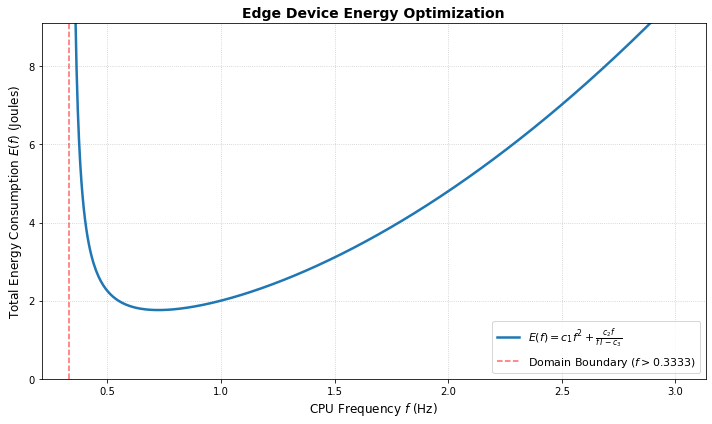

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define physical constants
c1 = 1  # Hardware capacitance constant
c2 = 2  # Channel-dependent constant
c3 = 1  # CPU cycles for the task
T  = 3  # Latency deadline (seconds)

# 2. Determine the valid domain
f_min = c3 / T
f = np.linspace(f_min + 0.01, 3.0, 500)

# 3. Calculate the Energy Function E(f)
energy = c1 * (f**2) + (c2 * f) / (f * T - c3)

# 4. Create the Plot
plt.figure(figsize=(10, 6))
plt.plot(f, energy, label=r'$E(f) = c_1 f^2 + \frac{c_2 f}{f T - c_3}$',
         color='#1f77b4', linewidth=2.5)

plt.axvline(x=f_min, color='red', linestyle='--', alpha=0.6,
            label=f'Domain Boundary ($f > {f_min:.4f}$)')

# 5. Formatting the chart
plt.title('Edge Device Energy Optimization', fontsize=14, fontweight='bold')
plt.xlabel('CPU Frequency $f$ (Hz)', fontsize=12)
plt.ylabel('Total Energy Consumption $E(f)$ (Joules)', fontsize=12)

# Limit Y-axis to prevent the asymptote from squashing the rest of the curve
plt.ylim(0, np.percentile(energy, 95))

plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

### 2.3

The code is as below,

In [9]:
import cvxpy as cp

# 1. Define the physical constants
c1 = 1e-18   # Hardware capacitance
c2 = 0.1     # Channel-dependent constant
c3 = 10**9   # CPU cycles required
T  = 2.0     # Latency deadline (seconds)

# 2. Define the Optimization Variables
f = cp.Variable(pos=True)
t_tx = cp.Variable(pos=True)

# 3. Define the Objective Function
objective_fn = c1 * cp.power(f, 2) + c2 * cp.inv_pos(t_tx)
objective = cp.Minimize(objective_fn)

# 4. Define the Constraints
constraints = [(c3 * cp.inv_pos(f) + t_tx) / T <= 1]

# 5. Solve the Problem
prob = cp.Problem(objective, constraints)
prob.solve(gp=True)

# 6. Output the Results
if prob.status == cp.OPTIMAL:
    print("="*40)
    print("OPTIMAL SOLUTION FOUND")
    print("="*40)
    print(f"Optimal CPU Frequency (f*):      {f.value:.4f} Hz")
    print(f"Optimal Trans. Time (t_tx*):     {t_tx.value:.4f} seconds")
    print(f"Computation Time (t_comp):      {(c3/f.value):.4f} seconds")
    print(f"Minimum Total Energy:           {prob.value:.8f} Joules")
    print("="*40)
else:
    print("Solver could not find an optimal solution.")

OPTIMAL SOLUTION FOUND
Optimal CPU Frequency (f*):      639774744.5752 Hz
Optimal Trans. Time (t_tx*):     0.4369 seconds
Computation Time (t_comp):      1.5631 seconds
Minimum Total Energy:           0.63817093 Joules


## Question 3 (Aloha communication protocol) (Mark: 3 + 15 + 2 = 20 points)

**Aloha** is a well-known random access or _MAC_ (Media/multiple Access Control) communication protocol. In this system, multiple independent transmitters send packets (called $\textit{frames}$) to a single receiver over a shared channel. In the original Aloha, each transmitter sends whenever it has data, without coordinating with others. If two or more packets overlap in time, a collision occurs and the packets are lost; the transmitters then retry after a random delay.

In a more advanced setup, called **slotted Aloha**, the nodes can only transmit at the beginning of time slots, which are kept by a global/shared clock. The operations of slotted ALOHA in each node are decribed as follows:

* If there is only one frame (namely only one active transmitter) in a slot, then the transmission is successful and the slot is said to be a successful slot.
* If two or more frames (namely two or more active transmitters) collide in a slot, then the transmission is failed and a re-transmission is considered for each frame involved in the collision. The transmitter will retransmit its frame in each subsequent slot with probability $p$ until the frame is transmitted without a collision, where $0 \leq p \leq 1$.

Assume that there are $N$ transmitters and each transmitter independently attempts to transmit a frame in each slot with probability $p$. For one slot, let $S$ denote the _success probability_ that this slot is a successful slot.

Answer the following questions:
1. Provide an expression of $S$ defined above.
2. To maximise the $S$, define the optimisation problem to find the optimal value $p$. Note that the constraint $0 \leq p \leq 1$
should be taken into consideration. Clearly identify the objective and decision variable(s). Is the objective convex or concave? Show through derivation. Find the optimality conditions for this problem.
3. When $N$ tends to infinity, what is the maximal success probability $S$?

## Answer:

### 3.1

To make a successful transmission, only one transmitter can transfer the information while the other transmitters not active. The probability for this to happen is $S = Np(1-p)^{N-1}$.

### 3.2

* Decision variable: p

* Objective: maximize $S(p) = Np(1-p)^{N-1}$

* The first derivative for objective function is
\begin{aligned}
S(p) &= Np(1-p)^{N-1} \\
S'(p) &= \frac{d}{dp} \left[ Np(1-p)^{N-1} \right] \\
S'(p) &= N(1-p)^{N-1} + Np \cdot (N-1)(1-p)^{N-2} \cdot (-1) \\
S'(p) &= N(1-p)^{N-2} \left[ (1-p) - p(N-1) \right] \\
S'(p) &= N(1-p)^{N-2} (1 - Np)
\end{aligned}
The second derivative is
\begin{aligned}
S''(p) &= \frac{d}{dp} \left[ N(1-p)^{N-2}(1 - Np) \right] \\
S''(p) &= N \left[ (N-2)(1-p)^{N-3}(-1)(1-Np) + (1-p)^{N-2}(-N) \right] \\
S''(p) &= N(1-p)^{N-3} \left[ -(N-2)(1-Np) - N(1-p) \right] \\
S''(p) &= N(1-p)^{N-3} \left[ -(N - N^2p - 2 + 2Np) - (N - Np) \right] \\
S''(p) &= N(1-p)^{N-3} \left[ N^2p - 3Np + 2 - 2N \right]
\end{aligned}
The objective function S(p) is neither strictly concave nor strictly convex over the entire domain [0,1] for all N. However, in the region of interest near the maximum (where p≈1/N), the function behaves concavely.

* The optimal condition happens when the first derivative is equal to zero, which is
\begin{aligned}
S'(p) &= N(1-p)^{N-2} (1 - Np)=0\\
\end{aligned}
So, the optimal condition is
\begin{aligned}
p = 1/N
\end{aligned}

### 3.3

At optimal condition $p = 1/N$, the success probability is
$$
S = (1-1/N)^{N-1}
$$

When N tends to the infinity, according to the product limit definition of exponential function
$$
\lim_{N \to \infty} \left( 1 - \frac{1}{N} \right)^N = e^{-1} = \frac{1}{e} = 0.368
$$


## Question 4 (Geometric programming: power control in wireless network) (Mark: 3 + 7 + 6 + 4 = 20 points)

### Example: Power Control in Wireless Communication

 *Adapted from Boyd, Kim, Vandenberghe, and Hassibi,* "[A Tutorial on Geometric Programming](https://web.stanford.edu/~boyd/papers/pdf/gp_tutorial.pdf)."

The [power control problem in wireless communications](http://winlab.rutgers.edu/~narayan/PAPERS/PC%20for%20Wireless%20Data.pdf) aims to minimise the total transmitter power available across $N$ trasmitters while concurrently achieving good (or a pre-defined minimum) performance.

The technical setup is as follows. Each transmitter $i$ transmits with a power level $P_i$ bounded below and above by a minimum and maximum level. The power of the signal received from transmitter $j$ at receiver $i$ is $G_{ij} P_{j}$, where $G_{ij} > 0$ represents the path gain (often loss) from transmitter $j$ to receiver $i$. The signal power at the intended receiver $i$ is $G_{ii} P_i$, and the interference power at receiver $i$ from other transmitters is given by $\sum_{k \neq i} G_{ik}P_k$. The (background) noise power at receiver $i$ is $\sigma_i$. Thus, the _Signal to Interference and  Noise Ratio (SINR)_ of the $i$th receiver-transmitter pair is

$$ S_i = \frac{G_{ii}P_i}{\sum_{k \neq i} G_{ik}P_k + \sigma_i }. $$

The minimum SINR represents a performance lower bound for this system, $S^{\text min}$.

The resulting optimisation problem is formulated as

$$
\begin{array}{ll}
\min_{P} & \sum_{i=1}^N P_i \\
\text{subject to} & P^{min} \leq P_i \leq P^{max}, \; \forall i \\
& \dfrac{G_{ii}P_i}{\sigma_i + \sum_{k \neq i} G_{ik}P_k} \geq S^{min} , \; \forall i \\
\end{array}
$$

### Answer the following questions: Wireless Power Control

Let $N=10$, $P^{min}=0.1$, $P^{max}=5$, $\sigma=0.2$ (same for all). Create a random path loss matrix $G$, where off-diagonal elements are between $0.1$ and $0.9$ and the diagonal elements are equal to $1$.
1. Convert the problem into standard Geometric Programming form.
2. Solve the problem first with $S^{min}=0$, and we recommand to use *cvxpy* or *scipy*. Output and plot the power levels and SINRs that you obtain.
3. What happens if you choose an $S^{min}$ that is larger? Solve the problem again and document your results. What happens if you choose a very large $S^{min}$? Observe and comment.
4. Suppose that there are only 3 transmitter-receiver pairs, e.g., $N=3$, if the SINR of the $i$th receiver-transmitter pair is

$$ S_i = \frac{G_{ii}P_i}{0.5 \sum_{j \neq i}^{N} (G_{ij} P_j \sum_{k \neq i, k \neq j}^{N} G_{ik} P_k )+ \sigma_i }. $$

and other settings remain the same, please try to convert the problem into standard Geometric Programming form again.

**Note:**
* if you are in the minority of people who have problem installing *cvxpy* or *scipy*, then you can use other packages or even Matlab.
* the problem in (1) can be converted to either Geometric Programming or Linear Programming form, while the problem in (4) can not be converted to Linear Programming anymore.

## Question 5 (Gradient descent for Logistic Regression) (Mark: 5 + 10 + 5 = 20 points)



### Background
Suppose we are given a binary classification dataset consisting of $n$ independent samples $S=\{(\mathbf{x}_i,y_i)\}^n_{i=1}$, where $\mathbf x_i∈\mathbb R^d$ represents the feature vector of the $i$-th sample and $y_i∈\{0,1\}$ is the corresponding label.


Logistic regression models the probability of the event $Y=1$ given the feature vector $\mathbf x$. Specifically, logistic regression assumes a linear relationship between the features $\mathbf{x}$ and the log-odds of the event $Y = 1$:

$$
\log \frac{p(y = 1|\mathbf{x})}{1 - p(y = 1|\mathbf{x})} = \mathbf{x}^\top \mathbf{w},
$$
where $\mathbf w\in \mathbb R^d$ is the weight vector.

Given the dataset, we estimate the weight vector $\mathbf w$ by minimizing the empirical risk under the log-loss (also known as cross-entropy loss):

$$
\hat{R}(\mathbf{w}) = - \frac{1}{n} \sum_{i = 1}^{n} \ell_\mathrm{log}(y_i, \mu_i(\mathbf{w})),
$$

where $\ell_\mathrm{log}(y, \mu) = y \log \mu + (1 - y) \log (1 - \mu)$.

In this exercise you will:

* derive the gradient,
* implement gradient descent from scratch,
* verify correctness by comparing with a standard library implementation.

---



### 5.1 — Mathematical Derivation

**1.** Given the expression of $\mu_i(\mathbf{w}): = \frac{1}{1 + \exp(-\mathbf{x}_i^\top \mathbf{w})}$

**2.** Give the expression the gradient of the empirical risk at iteration $t$
$$
\nabla_{\mathbf{w}} \hat{R}(\mathbf{w}_t) = \frac{1}{n} \sum_{i=1}^{n} (\mu_i - y_i) \mathbf{x}_i
$$

---

**3.** Using a fixed learning rate ($\eta>0$), write the gradient descent update rule at iteration $t+1$

$$
\mathbf{w}_{t+1} = \mathbf{w}_t - \frac{\eta}{n} \sum_{i=1}^{n} (\mu_i(\mathbf{w}_t) - y_i) \mathbf{x}_i
$$

Clearly specify all quantities appearing in the update, and note that $\mathbf{w},\mathbf x_i∈\mathbb{R}^{d}.$

| Quantity | Dimension |
| :--- | :--- |
| $\mathbf{w}_{t+1}$ | $\mathbb{R}^d$ |
| $\mathbf{w}_t$ | $\mathbb{R}^d$ |
| $\eta$ | $\mathbb{R}_{>0}$ |
| $n$ | $\mathbb{Z}^+$ |
| $y_i$ | $\{0, 1\}$ |
| $\mu_i$ | $(0, 1)$ |
| $\mathbf{x}_i$ | $\mathbb{R}^d$ |
---



### 5.2 — Programming Implementation 

You will now implement logistic regression trained using **batch gradient descent**.

Write a function ``fit_logistic(X, y, w_init, max_iter, tol, update_weight)``

that returns the learned parameter $\mathbf{w}$.

### Requirements

Your implementation should contain the following components:

---

### (a) Empirical risk function 

The function ``risk(X, y, w)``

that computes empircal risk under the log-loss.

---

### (b) Gradient function 

The function  ``grad_risk(X, y, w)``

that computes $\nabla_{\mathbf{w}} \hat{R}(\mathbf{w})$ for a given weight vector $\mathbf{w}$ and training data $\mathbf{X}$ and $\mathbf{y}$.

---

### (c) Optimization procedure 

Inside `fit_logistic`:

1. Initialize the weight vector $\mathbf{w}_0 = \mathbf 0 \in \mathbb{R}^d$ 

2. Perform gradient descent iterations (define the learning rate $\eta$ by yourselves) 

3. Stop when $\| \nabla_\mathbf{w} \hat{R}(\mathbf{w}_t) \|_\infty \leq \mathtt{tol}$ 


---

### (d) Visualization

Generate a **2-dimensional binary classification dataset** using the provided function and:

* plot the data points 
* plot the decision boundary of your trained model 


---



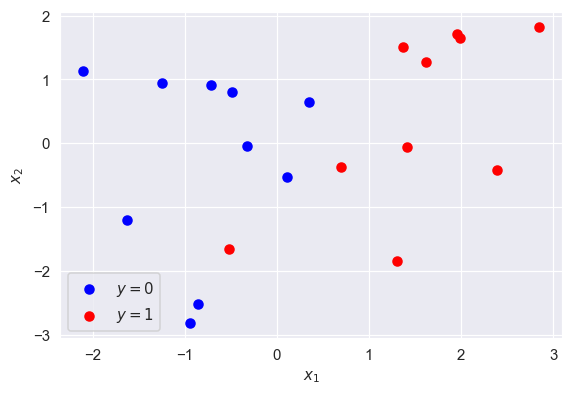

In [10]:
#function for generating synthetic data, set your student ID as the random seed. (keep it)
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 108


X, y = make_classification(n_samples = 20, n_features = 2, n_informative=2, n_redundant=0, random_state=1329017)
X_b = np.column_stack((np.ones_like(y), X))

plt.scatter(X[y==0,0], X[y==0,1], color='b', label="$y = 0$")
plt.scatter(X[y==1,0], X[y==1,1], color='r', label="$y = 1$")
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.show()

In [11]:
# #Your answer (fill the function)
# def fit_logistic(X, y, w_init=None, max_iter = 100, tol = 1e-9,
#                  update_weight = update_weight_gd, **kwargs):
#     """Fits a binary logistic regression model according to the given training
#     data
#
#     Parameters
#     ----------
#     X : array of shape (n_samples, n_features)
#         Feature matrix. The matrix must contain a constant column to
#         incorporate a non-zero bias.
#
#     y : array of shape (n_samples,)
#         Response relative to `X`. Binary classes must be encoded as 0 and 1.
#
#     w_init : array of shape (n_features,) default=None
#         Initial guess for the weights vector. Defaults to a vector of
#         zeroes.
#
#     max_iter : int, default=100
#         Maximum number of iterations
#
#     tol : float, default=1e-9
#         Stop when the inf-norm of the gradient falls below this value.
#
#     update_weight : callable, default=update_weight_gd
#         Callable that performs a weight update. Must have signature
#         (X, y, w, **kwargs). Defaults to GD.
#
#     **kwargs :
#         Keyword arguments passed to `update_weight`.
#
#     Returns
#     -------
#     w_history : list of arrays of shape (n_features,)
#         History of weight vectors
#     """
#
#     return w_history

In [ ]:
def update_weight_gd(X, y, w, learningrate, **kwargs):
    """
    Performs a single Gradient Descent update step for Logistic Regression.
    """
    n_samples = X.shape[0]

    # 1. Forward pass: compute probabilities mu
    z = X @ w
    mu = 1 / (1 + np.exp(-z))

    # 2. Compute the gradient: (1/n) * X^T * (mu - y)
    gradient = (1 / n_samples) * X.T @ (mu - y)

    # 3. Update step
    w_next = w - learningrate * gradient

    return w_next

In [241]:
def fit_logistic(X, y, w_init=None,learningrate=None, max_iter=100, tol=1e-9,
                 update_weight=update_weight_gd, **kwargs):
    """
    Fits a binary logistic regression model using gradient-based optimization.
    """
    n_samples, n_features = X.shape

    # 1. Initialize weights if not provided
    if w_init is None:
        w = np.zeros(n_features)
    else:
        w = np.array(w_init, dtype=float)

    # Initialize history with the starting weights
    w_history = [w.copy()]

    for i in range(max_iter):
        # 2. Stopping Criterion: Check the infinity norm of the gradient
        mu = 1 / (1 + np.exp(-X @ w))
        grad = (1 / n_samples) * X.T @ (mu - y)
        if np.linalg.norm(grad, np.inf) < tol:
            break

        # 3. Perform the weight update using the callable
        w_next = update_weight(X, y, w, learningrate, **kwargs)

        # 4. Update the current weight and record history
        w = w_next
        w_history.append(w.copy())

    return w_history

### 5.3 — Validation Against scikit-learn 

To verify correctness, compare the weights vector of your implementation with scikit-learn's implementation.

By default, scikit-learn includes **L2 regularization**.
You can disable it by setting ` {penalty = None}.`

1. The weights vector of your implementation 
2. The weights vector of scikit-learn's implementation 

In [251]:
from sklearn.linear_model import LogisticRegression

# 1. Run manual implementation
w_history = fit_logistic(
    X_b, y,
    learningrate=2
)
w_manual = w_history[-1]

# 2. Run scikit-learn implementation
sk_model = LogisticRegression(penalty=None,fit_intercept=False, tol=1e-9)
sk_model.fit(X_b, y)
w_sklearn = sk_model.coef_.flatten()

# 3. Display Results
comparison_df = pd.DataFrame({
    'Manual Weights': w_manual,
    'Scikit-Learn Weights': w_sklearn,
    'Difference': np.abs(w_manual - w_sklearn)
}, index=['Intercept (Bias)', 'Feature x1', 'Feature x2'])

print(comparison_df)

# Calculate Euclidean Distance between the two vectors
dist = np.linalg.norm(w_manual - w_sklearn)
print(f"\nEuclidean Distance between weight vectors: {dist:.10f}")

                  Manual Weights  Scikit-Learn Weights  Difference
Intercept (Bias)       -2.708893             -2.775424    0.066531
Feature x1              7.420765              7.310504    0.110261
Feature x2             -3.076942             -3.012058    0.064884

Euclidean Distance between weight vectors: 0.1442007423


C:\Users\Charl\Desktop\Capstone\LLM\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
